# Argus — Dense Feedforward NN Training

A plain feedforward (fully-connected) network trained on single-frame features — no windowing,
no recurrence. This is the non-recurrent alternative to the LSTM the earlier review evaluated
and settled in the LSTM's favor for the *sequence* model (see `03_model_training_lstm.ipynb`'s
Design Decision cell); this notebook exists separately because comparing a Dense NN against
RandomForest on the *same* single-frame task is still a useful baseline in its own right, and
much cheaper to train/iterate on than the LSTM.

**Reads:** `dataset_processed/frame_features.csv`, written by
[`02_dataset_creation_flat.ipynb`](./02_dataset_creation_flat.ipynb) — run that first.

**Writes:** `models/dense_nn_<VERSION>.keras`, `models/dense_feature_scaler_<VERSION>.joblib`.

**Feature set — deliberately different from `04_random_forest_training.ipynb`.** The RandomForest
notebook manually curates 7 features from the Spearman ranking, because a shallow tree ensemble
benefits from being pointed at the strongest signals directly. A Dense NN doesn't need that: its
first layer can learn its own per-feature weighting via gradient descent, so this notebook trains
on **all 58 per-frame features** (7 geometric ratios + 51 blendshapes) and lets the network decide
what matters, rather than re-imposing the RandomForest's feature list on a model that doesn't need
the same crutch.


## Setup

Mounts Drive and defines the paths/constants this notebook needs. Independent of any other notebook's in-memory state — only depends on `frame_features.csv`.


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

project_folder = "/content/drive/MyDrive/Argus"
print(f"Google Drive successfully mounted! Base project directory: {project_folder}")


Mounted at /content/drive
Google Drive successfully mounted! Base project directory: /content/drive/MyDrive/Argus


In [2]:
import os
import pandas as pd

# --- Argus project paths (must match 02_dataset_creation_flat.ipynb) ---
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
frame_features_csv_path = os.path.join(processed_folder, "frame_features.csv")

if not os.path.exists(frame_features_csv_path):
    raise FileNotFoundError(
        f"'{frame_features_csv_path}' not found. Run 02_dataset_creation_flat.ipynb first — "
        "this notebook only reads the dataset it produces, it doesn't build it."
    )

df_frame_features = pd.read_csv(frame_features_csv_path)
print(f"Loaded flat dataset: {len(df_frame_features)} frame rows, "
      f"{df_frame_features['subject'].nunique()} subjects.")


Loaded flat dataset: 173730 frame rows, 24 subjects.


In [3]:
import joblib
import datetime

# --- Model Management Configuration ---
FORCE_RETRAIN = True

VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dense_model_path = os.path.join(models_folder, f"dense_nn_{VERSION_STR}.keras")
dense_scaler_path = os.path.join(models_folder, f"dense_feature_scaler_{VERSION_STR}.joblib")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


✅ Model management initialized. Current version: 20260819_0129. Force retrain: True


## Preparing Features and Labels

All 58 per-frame feature columns become the input vector; identifier columns (`subject`, `parent_video`, `frame_idx`) are excluded from `X` but `subject` is kept separately as the split-grouping key.


In [4]:
import numpy as np

id_cols = ['subject', 'level', 'parent_video', 'frame_idx']
feature_cols = [c for c in df_frame_features.columns if c not in id_cols]

X = df_frame_features[feature_cols].to_numpy(dtype=np.float32)
y = (df_frame_features['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Alert, 1=Low Vigilant, 2=Drowsy
groups = df_frame_features['subject'].to_numpy()

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}, classes: {np.unique(y)}")


Feature columns (58): ['EAR_left', 'EAR_right', 'MAR', 'pitch', 'yaw', 'roll', 'ear_mar_valid', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft', 'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight', 'eyeBlinkLeft', 'eyeBlinkRight', 'eyeLookDownLeft', 'eyeLookDownRight', 'eyeLookInLeft', 'eyeLookInRight', 'eyeLookOutLeft', 'eyeLookOutRight', 'eyeLookUpLeft', 'eyeLookUpRight', 'eyeSquintLeft', 'eyeSquintRight', 'eyeWideLeft', 'eyeWideRight', 'jawForward', 'jawLeft', 'jawOpen', 'jawRight', 'mouthClose', 'mouthDimpleLeft', 'mouthDimpleRight', 'mouthFrownLeft', 'mouthFrownRight', 'mouthFunnel', 'mouthLeft', 'mouthLowerDownLeft', 'mouthLowerDownRight', 'mouthPressLeft', 'mouthPressRight', 'mouthPucker', 'mouthRight', 'mouthRollLower', 'mouthRollUpper', 'mouthShrugLower', 'mouthShrugUpper', 'mouthSmileLeft', 'mouthSmileRight', 'mouthStretchLeft', 'mouthStretchRight', 'mouthUpperUpLeft', 'mouthUpperUpRight', 'noseSneerLeft', 'noseSneerRight']
X shape: (17373

## Splitting and Scaling Data

Same group-aware split rationale as the LSTM and RandomForest notebooks: frames from the same subject/clip are correlated with each other, so a plain random split would leak near-duplicate samples across train/test.


In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import joblib

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train set size: {len(X_train)} frames ({len(set(groups[train_idx]))} subjects)")
print(f"Test set size: {len(X_test)} frames ({len(set(groups[test_idx]))} subjects)")
print("Subjects are disjoint between training and testing sets (group-aware split).")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, dense_scaler_path)
print(f"💾 Scaler saved: {dense_scaler_path}")


Train set size: 136106 frames (19 subjects)
Test set size: 37624 frames (5 subjects)
Subjects are disjoint between training and testing sets (group-aware split).
💾 Scaler saved: /content/drive/MyDrive/Argus/models/dense_feature_scaler_20260819_0129.joblib


## Dense Model Definition

A small fully-connected network: two hidden layers with `BatchNormalization` and `Dropout` for
regularization, softmax output over the 3 drowsiness classes. This is intentionally simple —
the point of this notebook is a non-recurrent baseline on single-frame features, not to compete
with the LSTM's temporal modeling.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import numpy as np

num_classes = len(np.unique(y))

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(num_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,771 (65.51 KB)

 Trainable params: 16,387 (64.01 KB)

 Non-trainable params: 384 (1.50 KB)

## Dense Model Training

`class_weight` for the same reason as the LSTM and RandomForest: the `Drowsy` class is plausibly
the rarest (it's the one level that had to be partly acted rather than self-recorded) and the
most safety-critical to not neglect. Computed from the actual training-set label distribution.


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import os

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint(filepath=os.path.join(models_folder, 'best_dense_nn.keras'), monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train).tolist(), weights))

print("🚀 Training Dense NN...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    class_weight=weight_dict,
    verbose=1,
)

model.save(dense_model_path)
print(f"💾 Model saved: {dense_model_path}")


🚀 Training Dense NN...
Epoch 1/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8222 - loss: 0.6039 - val_accuracy: 0.3012 - val_loss: 2.4490 - learning_rate: 0.0010
Epoch 2/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9327 - loss: 0.2961 - val_accuracy: 0.2580 - val_loss: 2.5557 - learning_rate: 0.0010
Epoch 3/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9506 - loss: 0.2190 - val_accuracy: 0.3710 - val_loss: 2.3063 - learning_rate: 0.0010
Epoch 4/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9567 - loss: 0.1893 - val_accuracy: 0.4187 - val_loss: 2.0850 - learning_rate: 0.0010
Epoch 5/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9612 - loss: 0.1704 - val_accuracy: 0.3343 - val_loss: 2.2236 - learning_rate: 0.0010
Epoch 6/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9642 - loss: 0.1614 - val_accuracy: 0.3963 - val_loss: 2.0103 - learning_rate: 0.0010
Epoch 7/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 4

## Dense Model Evaluation



Dense NN Test Loss: 1.9676
Dense NN Test Accuracy: 0.4496
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classification Report (Dense NN):
              precision    recall  f1-score   support

       Alert       0.65      0.41      0.51     14307
Low Vigilant       0.37      0.61      0.46      9901
      Drowsy       0.40      0.37      0.39     13416

    accuracy                           0.45     37624
   macro avg       0.48      0.46      0.45     37624
weighted avg       0.49      0.45      0.45     37624



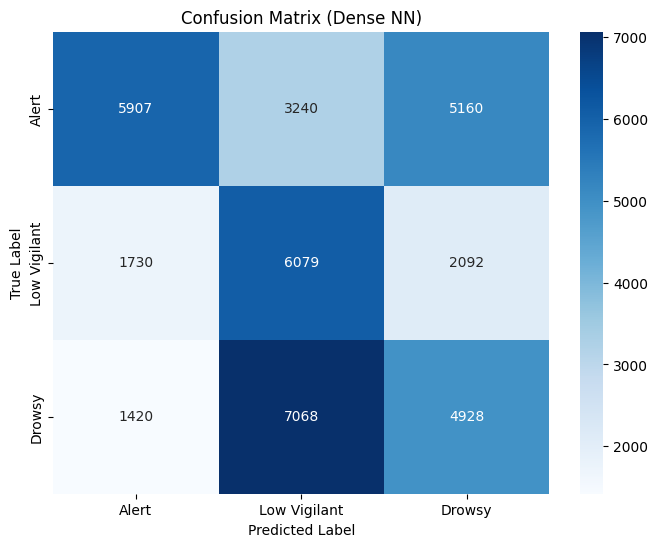

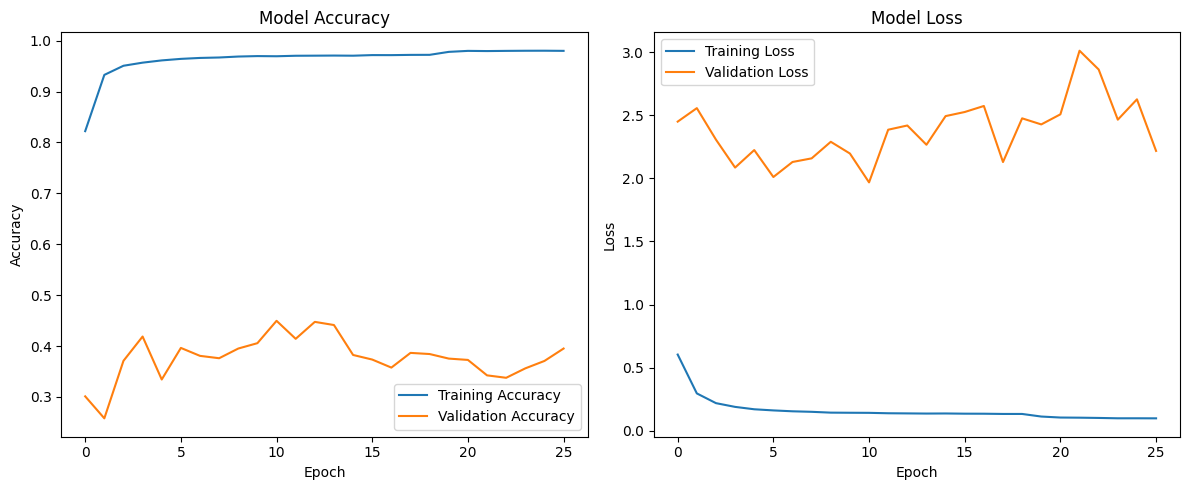

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nDense NN Test Loss: {loss:.4f}")
print(f"Dense NN Test Accuracy: {accuracy:.4f}")

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

CLASS_NAMES = ['Alert', 'Low Vigilant', 'Drowsy']
print("\nClassification Report (Dense NN):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Dense NN)')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


### Reading this result alongside RandomForest and the LSTM

Same caveat as `04_random_forest_training.ipynb`: single-frame accuracy should be expected to sit
below the LSTM's window-level accuracy, since neither this model nor RandomForest can see
duration/velocity-of-eye-closure — only the LSTM's sequence input can. Comparing this notebook's
result against RandomForest's is the fairer comparison (same dataset, same single-frame
constraint); comparing either against the LSTM is comparing across a fundamentally different task
difficulty, and the titulación report should frame it that way rather than as a straight accuracy
leaderboard.


## Diagnosing the Overfitting

A first run of this notebook hit **97%+ training accuracy by epoch 19** while validation accuracy
never exceeded **~41%** (and validation *loss* got worse over training, not better) — `EarlyStopping`
correctly restored the best checkpoint (lowest val_loss), giving a final **38.6% test accuracy**.
That gap opens up in literally the first epoch (81% train vs. 34% val), which is a much sharper
overfitting signature than model complexity alone would predict from a 16.7k-parameter network
that already has `Dropout`/`BatchNormalization`.

The more informative fact is that `04_random_forest_training.ipynb` — a completely different
model family — plateaus in the **same ~33-40% band**. Two very different models capping out
together points at a **data-level ceiling**, not an architecture problem. The specific mechanism
worth checking directly: if some subjects are heavily skewed toward one drowsiness level (quite
plausible — Argus's own subjects each did staged, mostly single-condition recording sessions),
the model can shortcut "how drowsy is this frame" with "which subject's face is this," which
works almost perfectly on training subjects and collapses completely on the 5 held-out ones this
group-aware split intentionally never lets it see.


### Step 1 — Subject × Level Distribution (Confound Check)

If training subjects are heavily skewed toward one level each, that's direct evidence for the shortcut-learning explanation above — worth checking before assuming this is purely a tuning problem.


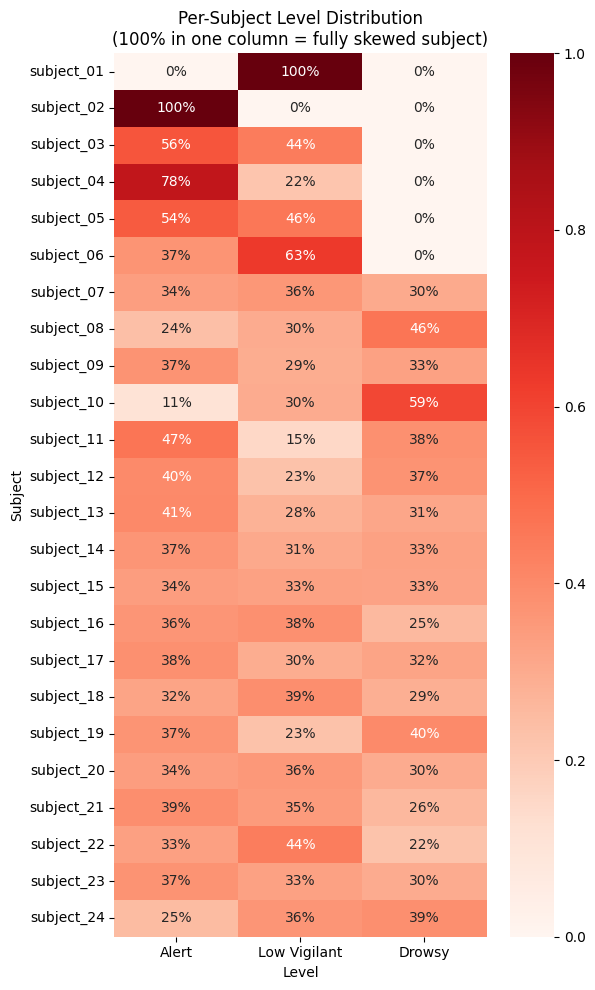

Subjects with >95% of their frames in a single level: 2 / 24
Mean max-class share across subjects: 49.1%

✅ Subjects aren't strongly skewed -- the confound explanation is weaker than expected; the overfitting may be more about raw per-frame noise/capacity than a subject-identity shortcut. Still worth trying Step 2/3 to see if either moves the needle.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

subject_level_counts = pd.crosstab(df_frame_features['subject'], df_frame_features['level'])
subject_level_pct = subject_level_counts.div(subject_level_counts.sum(axis=1), axis=0)

plt.figure(figsize=(6, 10))
sns.heatmap(subject_level_pct, annot=True, fmt='.0%', cmap='Reds', vmin=0, vmax=1,
            xticklabels=CLASS_NAMES if 'CLASS_NAMES' in globals() else ['Alert', 'Low Vigilant', 'Drowsy'])
plt.title('Per-Subject Level Distribution\n(100% in one column = fully skewed subject)')
plt.xlabel('Level')
plt.ylabel('Subject')
plt.tight_layout()
plt.show()

max_share = subject_level_pct.max(axis=1)
fully_skewed = (max_share > 0.95).sum()
print(f"Subjects with >95% of their frames in a single level: {fully_skewed} / {len(max_share)}")
print(f"Mean max-class share across subjects: {max_share.mean():.1%}")
if max_share.mean() > 0.7:
    print("\n⚠️  Strong subject/level confound -- the shortcut-learning explanation above is "
          "well supported. Regularizing the NN further is unlikely to fix this on its own; "
          "Step 3 below (per-subject normalization) is the more relevant next move.")
else:
    print("\n✅ Subjects aren't strongly skewed -- the confound explanation is weaker than "
          "expected; the overfitting may be more about raw per-frame noise/capacity than a "
          "subject-identity shortcut. Still worth trying Step 2/3 to see if either moves the needle.")


### Step 2 — Stronger Regularization

A second pass with more aggressive `Dropout`, L2, and label smoothing, plus a lower learning rate and longer patience -- this addresses capacity-driven overfitting. If Step 1 showed a strong subject/level confound, expect this to help only modestly; the ceiling is more likely set by Step 3.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

model_reg = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(num_classes, activation='softmax'),
])

model_reg.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stopping_reg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_reg = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train).tolist(), weights))

print("🚀 Training more heavily regularized Dense NN...")
history_reg = model_reg.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping_reg, reduce_lr_reg],
    class_weight=weight_dict,
    verbose=1,
)


🚀 Training more heavily regularized Dense NN...
Epoch 1/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5523 - loss: 1.7343 - val_accuracy: 0.3778 - val_loss: 1.6984 - learning_rate: 5.0000e-04
Epoch 2/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7731 - loss: 0.8188 - val_accuracy: 0.4691 - val_loss: 1.5082 - learning_rate: 5.0000e-04
Epoch 3/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8632 - loss: 0.4939 - val_accuracy: 0.4227 - val_loss: 1.7913 - learning_rate: 5.0000e-04
Epoch 4/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8923 - loss: 0.3899 - val_accuracy: 0.4063 - val_loss: 1.8809 - learning_rate: 5.0000e-04
Epoch 5/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9042 - loss: 0.3507 - val_accuracy: 0.4074 - val_loss: 2.0750 - learning_rate: 5.0000e-04
Epoch 6/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9079 - loss: 0.3341 - val_accuracy: 0.3972 - val_loss: 1.9696 - learning_rate: 5.0000e-0

Regularized Dense NN -- Test Loss: 1.5082, Test Accuracy: 0.4691
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classification Report (Regularized Dense NN):
              precision    recall  f1-score   support

       Alert       0.59      0.40      0.48     14307
Low Vigilant       0.42      0.57      0.48      9901
      Drowsy       0.44      0.47      0.45     13416

    accuracy                           0.47     37624
   macro avg       0.48      0.48      0.47     37624
weighted avg       0.49      0.47      0.47     37624



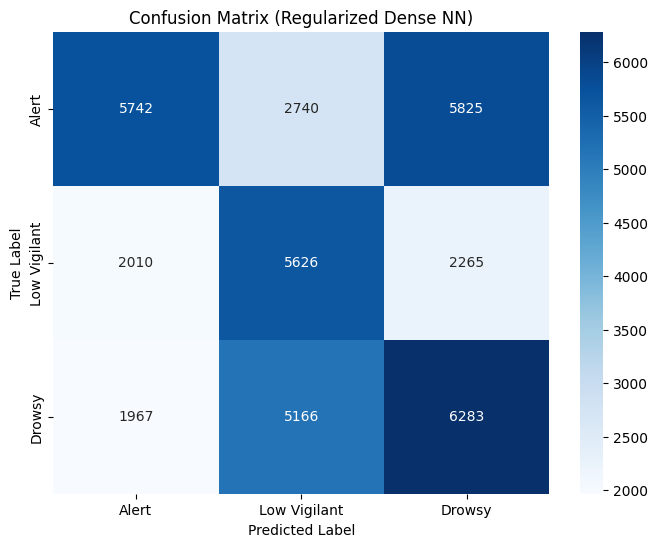

In [11]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loss_reg, accuracy_reg = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Regularized Dense NN -- Test Loss: {loss_reg:.4f}, Test Accuracy: {accuracy_reg:.4f}")

y_pred_reg = np.argmax(model_reg.predict(X_test_scaled), axis=1)
print("\nClassification Report (Regularized Dense NN):")
print(classification_report(y_test, y_pred_reg, target_names=CLASS_NAMES))

conf_matrix_reg = confusion_matrix(y_test, y_pred_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Regularized Dense NN)')
plt.show()


### Step 3 — Per-Subject-Normalized Features

Same technique as `04_random_forest_training.ipynb`'s Step 3: each feature is z-scored within
each subject (using only that subject's own data, not labels), removing between-person baseline
differences. If Step 1 showed a strong subject/level confound, this is the step most likely to
actually move the needle, since it removes the raw-value "subject signature" the model could
otherwise shortcut through. Same deployment caveat as the RF notebook applies: this requires a
per-driver calibration mechanism that doesn't exist yet if adopted for real deployment, not just
this diagnostic.


🚀 Training Dense NN on per-subject-normalized features...
Epoch 1/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5378 - loss: 1.7157 - val_accuracy: 0.3841 - val_loss: 1.5117 - learning_rate: 5.0000e-04
Epoch 2/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7526 - loss: 0.8424 - val_accuracy: 0.4067 - val_loss: 1.5174 - learning_rate: 5.0000e-04
Epoch 3/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8256 - loss: 0.5767 - val_accuracy: 0.4280 - val_loss: 1.5123 - learning_rate: 5.0000e-04
Epoch 4/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8496 - loss: 0.4944 - val_accuracy: 0.4329 - val_loss: 1.5794 - learning_rate: 5.0000e-04
Epoch 5/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8597 - loss: 0.4629 - val_accuracy: 0.4218 - val_loss: 1.5825 - learning_rate: 5.0000e-04
Epoch 6/100
1047/1064 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.4465
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000

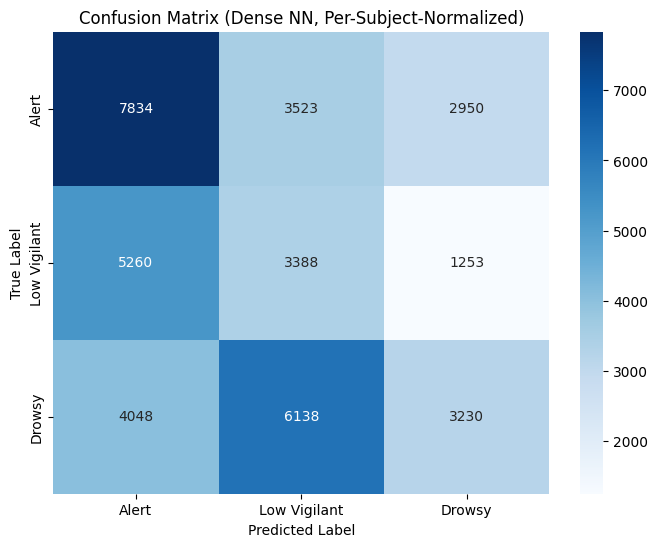

In [12]:
df_norm = df_frame_features.copy()
df_norm[feature_cols] = df_norm.groupby('subject')[feature_cols].transform(
    lambda s: (s - s.mean()) / (s.std() + 1e-8)
)

X_subj = df_norm[feature_cols].to_numpy(dtype=np.float32)
X_subj_train, X_subj_test = X_subj[train_idx], X_subj[test_idx]

scaler_subj = StandardScaler()
X_subj_train_scaled = scaler_subj.fit_transform(X_subj_train)
X_subj_test_scaled = scaler_subj.transform(X_subj_test)

model_subj = Sequential([
    Input(shape=(X_subj_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(num_classes, activation='softmax'),
])
model_subj.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training Dense NN on per-subject-normalized features...")
history_subj = model_subj.fit(
    X_subj_train_scaled, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_subj_test_scaled, y_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ],
    class_weight=weight_dict,
    verbose=1,
)

loss_subj, accuracy_subj = model_subj.evaluate(X_subj_test_scaled, y_test, verbose=0)
print(f"\nPer-subject-normalized Dense NN -- Test Loss: {loss_subj:.4f}, Test Accuracy: {accuracy_subj:.4f}")

y_pred_subj = np.argmax(model_subj.predict(X_subj_test_scaled), axis=1)
print("\nClassification Report (Per-Subject-Normalized Dense NN):")
print(classification_report(y_test, y_pred_subj, target_names=CLASS_NAMES))

conf_matrix_subj = confusion_matrix(y_test, y_pred_subj)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_subj, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Dense NN, Per-Subject-Normalized)')
plt.show()


### Reading these results together, and against RandomForest

* **If Step 1's crosstab showed strongly skewed subjects** and **Step 3 clearly beats both the
  original run and Step 2** → confirms the subject/level confound is the real driver. Compare
  Step 3's accuracy against `04_random_forest_training.ipynb`'s equivalent per-subject-normalized
  result — if both move by a similar amount, that's a consistent, reportable finding for the
  titulación report: raw per-frame absolute feature values don't transfer across people, for
  either model family, and normalization/calibration (not model choice) is the lever that matters.
* **If Step 2 alone (no normalization) already closes most of the gap** → this was more of an
  under-regularized-capacity problem than a data confound, despite the subject skew.
* **If none of Steps 1-3 meaningfully change the ~35-40% ceiling** → that's the strongest evidence
  yet that a single frame's information content is the real limit (no amount of per-frame feature
  engineering can recover the duration/velocity-of-eye-closure signal only a sequence carries),
  which is the core argument for the LSTM being the right model for deployment rather than
  either of these single-frame baselines.


## Feature & Data Augmentation: Enriched Features + SMOTE/Noise

Same idea as `04_random_forest_training.ipynb`'s equivalent section: train on
`frame_features_enriched.csv` (all 58 raw + rolling/temporal columns from
`02_dataset_creation_flat.ipynb`'s enrichment section) instead of the flat notebook's raw
features, then layer SMOTE oversampling and Gaussian-noise-jitter regularization on top.

**Calibrated expectation, same as the RF notebook:** SMOTE and noise-jitter are robustness
techniques, not new information -- expect a small, not dramatic, effect from them. If there's a
real jump here, it should come from the enriched features carrying temporal signal the original
flat features didn't have (check `02_dataset_creation_flat.ipynb`'s enrichment sanity-check cell).


### Load the Enriched Dataset and Split

A fresh group-aware split, for the same reason as the RF notebook's equivalent section: `frame_features_enriched.csv` is sorted differently (by clip/frame order) than `frame_features.csv`, so row positions from the original split don't line up. Same `random_state=42` + subject grouping means the same subjects end up in train/test regardless.


In [13]:
import pandas as pd
import numpy as np

enriched_csv_path = os.path.join(processed_folder, "frame_features_enriched.csv")
if not os.path.exists(enriched_csv_path):
    raise FileNotFoundError(
        f"'{enriched_csv_path}' not found. Run the \"Temporal Feature Enrichment\" section at "
        "the end of 02_dataset_creation_flat.ipynb first."
    )

df_enriched = pd.read_csv(enriched_csv_path)
enriched_id_cols = ['subject', 'level', 'parent_video', 'frame_idx']
enriched_feature_cols = [c for c in df_enriched.columns if c not in enriched_id_cols]

X_enr_full = df_enriched[enriched_feature_cols].to_numpy(dtype=np.float32)
y_enr_full = (df_enriched['level'].to_numpy(dtype=np.int32) - 1)
groups_enr_full = df_enriched['subject'].to_numpy()

print(f"Enriched feature count: {len(enriched_feature_cols)} (vs. {len(feature_cols)} original flat)")
print(f"X shape: {X_enr_full.shape}")


Enriched feature count: 154 (vs. 58 original flat)
X shape: (173730, 154)


In [14]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

gss_enr = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_enr, test_idx_enr = next(gss_enr.split(X_enr_full, y_enr_full, groups=groups_enr_full))

X_enr_train_raw, X_enr_test_raw = X_enr_full[train_idx_enr], X_enr_full[test_idx_enr]
y_enr_train, y_enr_test = y_enr_full[train_idx_enr], y_enr_full[test_idx_enr]

scaler_enr = StandardScaler()
X_enr_train_scaled = scaler_enr.fit_transform(X_enr_train_raw)
X_enr_test_scaled = scaler_enr.transform(X_enr_test_raw)

print(f"Train: {len(X_enr_train_scaled)} frames ({len(set(groups_enr_full[train_idx_enr]))} subjects)")
print(f"Test:  {len(X_enr_test_scaled)} frames ({len(set(groups_enr_full[test_idx_enr]))} subjects)")


Train: 136106 frames (19 subjects)
Test:  37624 frames (5 subjects)


### Experiment 1 — Dense NN on All Enriched Features

Same regularized architecture as the earlier Step 2 (heavier dropout/L2), just given the enriched feature set instead of the original 58 flat columns.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

model_enr = Sequential([
    Input(shape=(X_enr_train_scaled.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax'),
])
model_enr.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

weights_enr = compute_class_weight('balanced', classes=np.unique(y_enr_train), y=y_enr_train)
weight_dict_enr = dict(zip(np.unique(y_enr_train).tolist(), weights_enr))

print("🚀 Training Dense NN on all enriched features...")
history_enr = model_enr.fit(
    X_enr_train_scaled, y_enr_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_enr_test_scaled, y_enr_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ],
    class_weight=weight_dict_enr,
    verbose=1,
)


🚀 Training Dense NN on all enriched features...
Epoch 1/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7383 - loss: 1.8687 - val_accuracy: 0.3313 - val_loss: 2.7120 - learning_rate: 5.0000e-04
Epoch 2/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9148 - loss: 0.5360 - val_accuracy: 0.3284 - val_loss: 2.6414 - learning_rate: 5.0000e-04
Epoch 3/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9434 - loss: 0.2990 - val_accuracy: 0.3114 - val_loss: 2.7205 - learning_rate: 5.0000e-04
Epoch 4/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9515 - loss: 0.2435 - val_accuracy: 0.3668 - val_loss: 2.4711 - learning_rate: 5.0000e-04
Epoch 5/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9554 - loss: 0.2223 - val_accuracy: 0.3786 - val_loss: 2.6982 - learning_rate: 5.0000e-04
Epoch 6/100
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9585 - loss: 0.2113 - val_accuracy: 0.3430 - val_loss: 2.9924 - learning_rate: 5.0000e

Enriched-features Dense NN -- Test Loss: 2.4711, Test Accuracy: 0.3668
1176/1176 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classification Report (Enriched-Features Dense NN):
              precision    recall  f1-score   support

       Alert       0.58      0.42      0.49     14307
Low Vigilant       0.35      0.42      0.38      9901
      Drowsy       0.24      0.28      0.26     13416

    accuracy                           0.37     37624
   macro avg       0.39      0.37      0.37     37624
weighted avg       0.40      0.37      0.38     37624



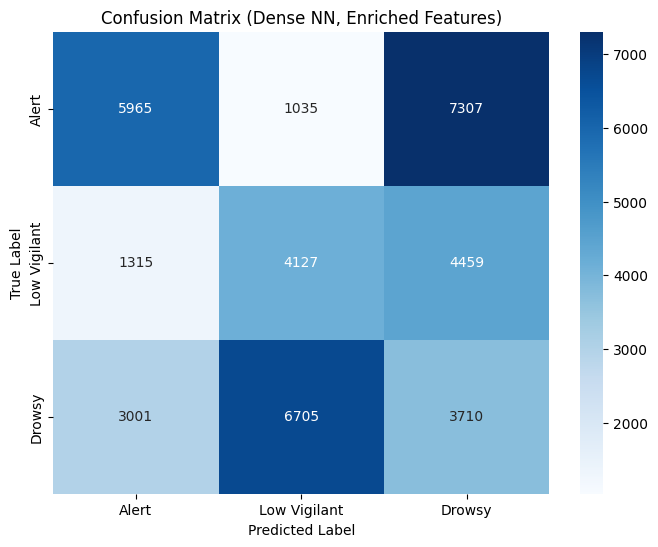

In [16]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loss_enr, accuracy_enr = model_enr.evaluate(X_enr_test_scaled, y_enr_test, verbose=0)
print(f"Enriched-features Dense NN -- Test Loss: {loss_enr:.4f}, Test Accuracy: {accuracy_enr:.4f}")

y_pred_enr = np.argmax(model_enr.predict(X_enr_test_scaled), axis=1)
print("\nClassification Report (Enriched-Features Dense NN):")
print(classification_report(y_enr_test, y_pred_enr, target_names=CLASS_NAMES))

cm_enr = confusion_matrix(y_enr_test, y_pred_enr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_enr, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.title('Confusion Matrix (Dense NN, Enriched Features)')
plt.show()


### Experiment 2 — SMOTE + Gaussian Noise Jitter

`SMOTE` on the training set only (same leakage caveat as the RF notebook — never apply it to the
test set). `GaussianNoise` as the model's first layer is Keras' built-in way to do noise-jitter
augmentation correctly: it only injects noise during `training=True` and is a no-op at inference,
so it can't affect evaluation — the same technique the LSTM's regularized architecture already
uses (see `03_model_training_lstm.ipynb`'s model definition).


In [17]:
!pip install -q imbalanced-learn


Before SMOTE: 136106 rows, class counts: {np.int32(0): np.int64(47788), np.int32(1): np.int64(45585), np.int32(2): np.int64(42733)}
After SMOTE:  143364 rows, class counts: {np.int32(0): np.int64(47788), np.int32(1): np.int64(47788), np.int32(2): np.int64(47788)}
🚀 Training Dense NN on SMOTE-resampled + noise-jittered enriched features...
Epoch 1/100
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7492 - loss: 1.7419 - val_accuracy: 0.2977 - val_loss: 2.7694 - learning_rate: 5.0000e-04
Epoch 2/100
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9210 - loss: 0.4693 - val_accuracy: 0.3115 - val_loss: 2.7741 - learning_rate: 5.0000e-04
Epoch 3/100
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9441 - loss: 0.2841 - val_accuracy: 0.3550 - val_loss: 2.8510 - learning_rate: 5.0000e-04
Epoch 4/100
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9508 - loss: 0.2399 - val_accuracy: 0.3478 - val_loss: 2.7701 - learning_rate: 5.0000e-04
Epoch 5/100
1121/1121 ━

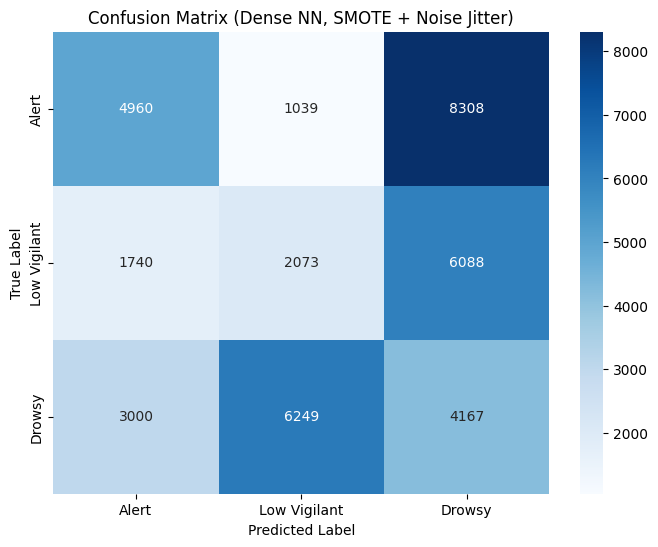

In [18]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.layers import GaussianNoise

smote = SMOTE(random_state=42)
X_smote_train, y_smote_train = smote.fit_resample(X_enr_train_scaled, y_enr_train)

print(f"Before SMOTE: {len(X_enr_train_scaled)} rows, class counts: {dict(zip(*np.unique(y_enr_train, return_counts=True)))}")
print(f"After SMOTE:  {len(X_smote_train)} rows, class counts: {dict(zip(*np.unique(y_smote_train, return_counts=True)))}")

model_smote = Sequential([
    Input(shape=(X_smote_train.shape[1],)),
    GaussianNoise(0.05),  # active only during training -- forces robustness to small feature jitter

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax'),
])
model_smote.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training Dense NN on SMOTE-resampled + noise-jittered enriched features...")
history_smote = model_smote.fit(
    X_smote_train, y_smote_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_enr_test_scaled, y_enr_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ],
    verbose=1,
    # No class_weight here -- SMOTE already balanced the classes by construction.
)

loss_smote, accuracy_smote = model_smote.evaluate(X_enr_test_scaled, y_enr_test, verbose=0)
print(f"\nSMOTE+noise Dense NN -- Test Loss: {loss_smote:.4f}, Test Accuracy: {accuracy_smote:.4f}")

y_pred_smote = np.argmax(model_smote.predict(X_enr_test_scaled), axis=1)
print("\nClassification Report (SMOTE+Noise Dense NN):")
print(classification_report(y_enr_test, y_pred_smote, target_names=CLASS_NAMES))

cm_smote = confusion_matrix(y_enr_test, y_pred_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.title('Confusion Matrix (Dense NN, SMOTE + Noise Jitter)')
plt.show()


### Reading All of This Together

Same interpretation logic as the RF notebook's equivalent section:

* A **big jump from the original flat-feature runs to `model_enr` (enriched features)** is the
  important one — it means the rolling/temporal columns are carrying real signal.
* A **small jump from `model_enr` to `model_smote`** (SMOTE + noise) is expected — those are
  robustness techniques, not new information, so don't read a small change here as a negative
  result.
* Compare `model_enr`'s accuracy directly against `04_random_forest_training.ipynb`'s
  `rf_all_features`/`hgb_model` on the *same* enriched dataset — if both model families move by a
  similar amount from the same feature change, that's strong, reportable evidence that the
  enrichment (not model choice) is what matters here.
